In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config_seq
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor

Mesh warning: N_Z changed from 50 to 54
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [3]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)

In [4]:
Ns = [[15, 65, 40], [15, 65, 40]]
cfgs = generate_config_seq(data, Ns)

for i in range(len(cfgs)):
    cfgs[i].HP.material.h_cond = 150

reactors = [VapourReactor(cfg) for cfg in cfgs]
reactors[-1].variable_r_eff = True
reactors[-1].set_variable_k(True)

Mesh warning: N_Z changed from 40 to 27
Mesh warning: Fuel pin N_Z changed from 18 to 15
Mesh warning: Neutronics N_Z changed from 18 to 15
Mesh warning: N_Z changed from 40 to 27
Mesh warning: Fuel pin N_Z changed from 18 to 15
Mesh warning: Neutronics N_Z changed from 18 to 15


In [5]:
solver = Solver(reactors, iterate=True)
solver.fsolve()

# solver = Solver(reactors)
# solver.components.append(reactors[0])
# solver.components.append(reactors[1])
# solver.solutions.append(reactors[0].solve_picard()[1])
# solver.solutions.append(reactors[1].solve_picard()[1])

Solving Heat pipe initial values


/home/karlandersson/Programming/MasterThesisProject/utils/sodium_properties.py:72: RuntimeWarning: invalid value encountered in power
  return 1e3 * (393.37 * (1 - T_vapour / T_crit_Na) + 4398.6 * (1 - T_vapour / T_crit_Na)**(0.29302))
/home/karlandersson/Programming/MasterThesisProject/utils/sodium_properties.py:18: RuntimeWarning: invalid value encountered in sqrt
  return rho_c + f*(1 - T/T_c) + g*(1 - T/T_c)**h
/home/karlandersson/Programming/MasterThesisProject/utils/solver.py:61: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return solver_fn(component.get_residuals, x_initial, **valid_kwargs)


Running iteration 1 ...
Running iteration 2 ...


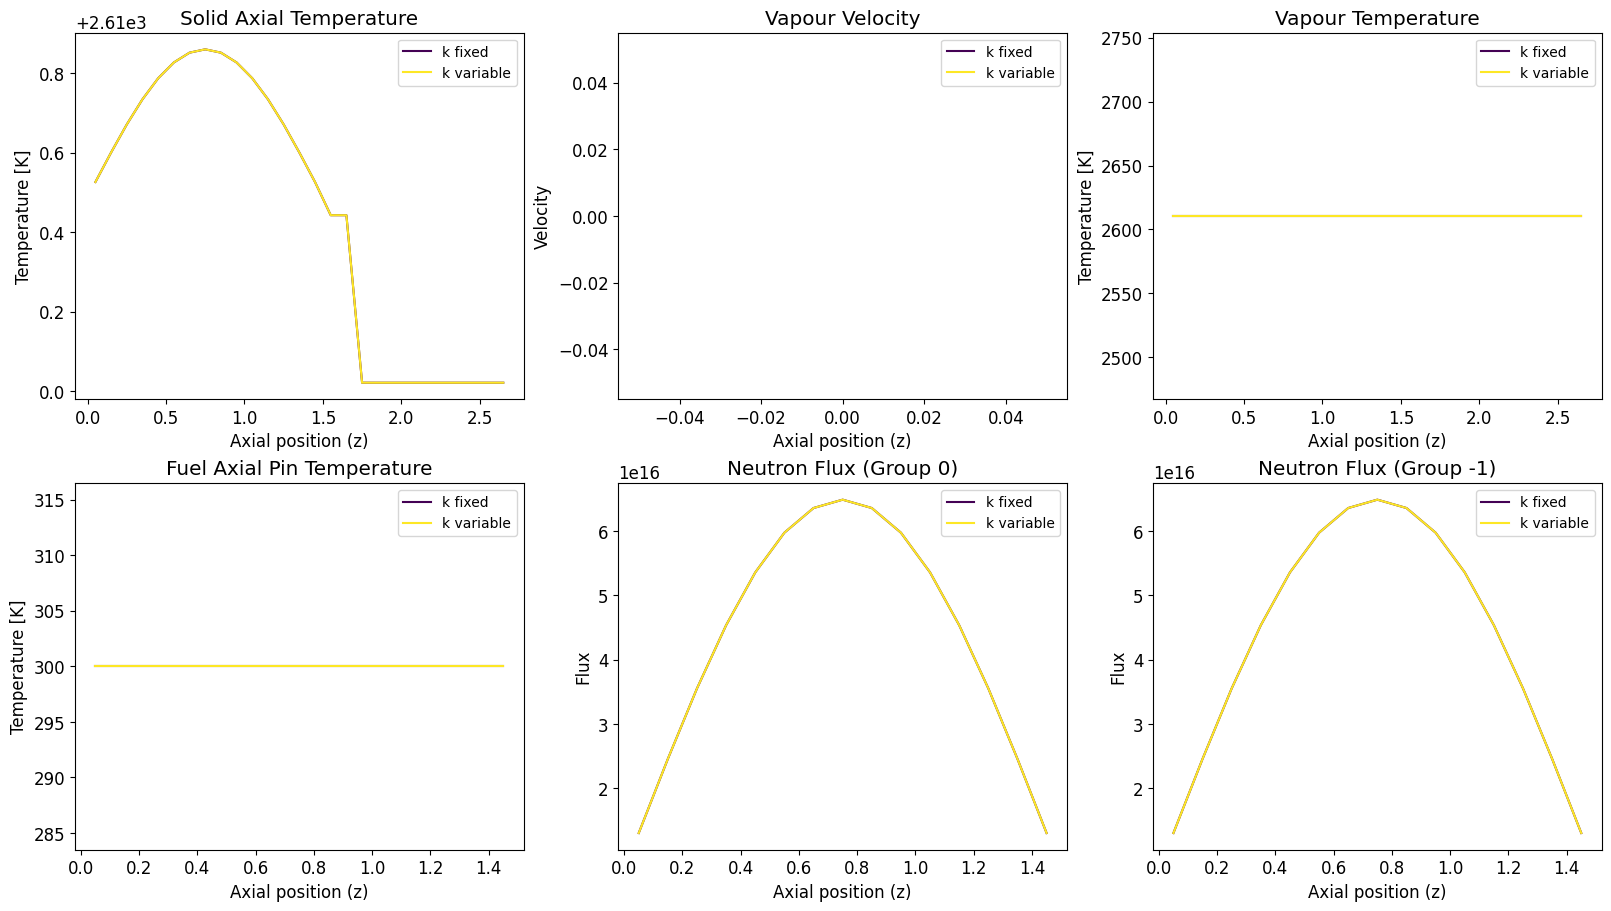

In [6]:
plot_reactor_solutions(solver)
